# 6. Agentic Workloads (1): What the Workload Looks Like

By [Kiwan Maeng](https://kiwanmaeng.com) ([LinkedIn](https://www.linkedin.com/in/kiwan-maeng-23b825165)) and [Claude Code](https://claude.com/claude-code) 🤖

Every workload so far has been a *request*: a prompt arrives, an answer streams
back, the request is gone. An agent works differently. Given one task — "find
which main course disappeared from this restaurant's menu between two dates" — it
issues dozens of LLM requests: it plans, picks a worker, calls a search tool,
reads the result, calls another tool, writes code, runs it, reads the error,
tries again, and finally answers. The user waits for the whole chain.

Three things differ from what we saw before. First, the requests are
*dependent*: turn *k+1* may not be able to start until turn *k* has finished and its tool
call has returned. Second, the prompts are long and repetitive, because each turn
resends the whole conversation plus the new tool output, which is lecture 5's
problem in its most extreme form. Third, the thing a user waits for is the task,
not the request: a p99 TTFT of 200 ms says little if the task takes six minutes.

The lecture works from recorded traces rather than a synthetic workload. They come
from [GAIATrace](https://github.com/psu-paws/Vidur-Agent)
([Kim et al., IISWC '26](https://arxiv.org/abs/2606.01725)), which recorded every
LLM request two agent systems issued while solving tasks from GAIA
([Mialon et al., ICLR '24](https://openreview.net/forum?id=fibxvahvs3)), a
benchmark of questions that need browsing, file handling and code to answer. The
corpus covers [OWL](https://github.com/camel-ai/owl)
([Hu et al., NeurIPS '25](https://arxiv.org/abs/2505.23885)), a multi-agent system,
and [MiroThinker](https://github.com/MiroMindAI/MiroThinker), a single agent with a
summariser. We look at both. Each request carries its prompt and output token ids,
the turns it depended on, and a separately measured tool latency. The traces ship
with the simulator, so they are already on your disk after `lsg.setup()`.
We are also in the process of extending GAIATrace to more setups and datasets!

:::{admonition} Learning goals
- Describe the structure of an agent session: turns, roles, dependencies,
  fan-out, and tool time.
- Explain why agent traffic is prompt-heavy in tokens but decode-heavy in time.
- Explain where an agent's prompt tokens come from, and why the prompt grows.
- Say how a single-agent and a multi-agent system differ in the traffic they
  produce.
:::

This is the first of two lectures on agent traffic. Here we look at what the
workload *is*; {doc}`07-agentic-workloads-2` puts it on a GPU.

## Setup

In [1]:
import os, sys, urllib.request
sys.path.insert(0, os.path.abspath("../../labs"))
try:
    import llm_systems_wo_gpus as lsg
except ImportError:  # outside the course repo (e.g. Colab): fetch the package
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/kwmaeng91/studying-llm-systems-without-gpus/main/labs/llm_systems_wo_gpus.py",
        "llm_systems_wo_gpus.py")
    import llm_systems_wo_gpus as lsg
lsg.setup()

import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
plt.rcParams.update({"figure.figsize": (6, 3.5), "axes.grid": True, "grid.alpha": .3})

SYSTEM = dict(model="Qwen/Qwen2.5-32B-Instruct", device="a100", tensor_parallel=2)

Simulator ready at /home/faculty/kvm6242/.llm-systems-wo-gpus/backend


`lsg.gaia_sessions` loads recorded sessions, one row per LLM request. We take 24
of them out of the 165 tasks OWL ran. Sessions containing a request longer than
the course's runtime predictor was fitted for are skipped, which removes the
largest tasks (again, this course uses a downsized simulator for simplicity).

In [2]:
sessions = lsg.gaia_sessions(num_sessions=24, seed=0)
print(f"{sessions.session.nunique()} sessions, {len(sessions)} LLM requests")
sessions.drop(columns="token_ids").head(8)

24 sessions, 673 LLM requests


,session,turn,model,role,dep,num_prefill_tokens,num_decode_tokens,tool_time
0,0,0,gpt-4o,plan,[],1355,199,0.000000
1,0,1,gpt-oss-120b,coordinate,[0],583,108,0.000000
2,0,2,gpt-4o,web search,[1],1500,36,0.000000
3,0,3,gpt-4o,web search,[2],1582,114,1.164357
4,0,4,gpt-oss-120b,coordinate,[3],1044,76,0.000000
5,0,5,gpt-oss-120b,coordinate,[4],1060,59,0.000000
6,0,6,gpt-4o,web search,[5],1610,36,0.000000
7,0,7,gpt-4o,web search,[6],1692,35,0.591392


The table gives a peek at how OWL solves a particular question.
Each row is one request to the model, which does the planning, coordination, web search, and so on.
Note that two models are used here: gpt-4o for tasks that do not require heavy thinking, and gpt-oss-120b for
tasks that require thinking. This is just how the authors of GAIATrace (that's me and my students!) decided to do it.

- `session` / `turn`: which task, and the position in it.
- `role`: which agent inside the system issued it. OWL is a *multi-agent* system:
  a planner splits the task, a coordinator assigns each subtask to a worker, and
  the workers (web search, code, browser, document reader) do it.
- `model`: which model served the request in the recording. OWL uses two, which
  GAIATrace calls the *main* and *sub* models, and gives each a different set of
  roles.
- `dep`: the turns that must finish before this one is released.
- `tool_time`: how long the tool call that this turn waited for actually took,
  measured by re-running the tool outside the agent.

:::{note}
The traces are released under CC-BY-4.0 as part of GAIATrace. The tasks
themselves come from the GAIA benchmark, whose
[dataset terms](https://huggingface.co/datasets/gaia-benchmark/GAIA) govern its
questions; what follows are short excerpts from one recorded run, shown so you
can see what a real agent prompt is made of.
:::

## What the model actually sees

The traces carry token ids, so we can read the requests back. Let's look at the
first turns of one session. (`lsg.decode` uses the same tokenizer the traces were
built with; it downloads a small vocabulary file the first time.)

In [3]:
def show(i, head=0, tail=0, out=400):
    """Print a trimmed view of request i's prompt and of what the model generated."""
    r = sessions.iloc[i]
    ids = json.loads(r.token_ids)
    prompt, output = lsg.decode(ids[:r.num_prefill_tokens]), lsg.decode(ids[r.num_prefill_tokens:])
    print(f"=== session {r.session} turn {r.turn} | role: {r.role} | "
          f"{r.num_prefill_tokens:,} prompt + {r.num_decode_tokens} output tokens "
          f"| tool wait before it: {r.tool_time:.1f} s")
    if head:
        print("--- prompt, first lines " + "-" * 40); print(prompt[:head].strip())
    if tail:
        print("--- prompt, last lines " + "-" * 41); print(prompt[-tail:].strip())
    print("--- generated " + "-" * 50); print(output[:out].strip(), "\n")

show(0, head=620, out=560)

=== session 0 turn 0 | role: plan | 1,355 prompt + 199 output tokens | tool wait before it: 0.0 s
--- prompt, first lines ----------------------------------------
<|start|>developer<|message|># Instructions

You are going to compose and decompose tasks.

<|end|><|start|>user<|message|>You need to split the given task into 
subtasks according to the workers available in the group.
The content of the task is:

I went to Virtue restaurant & bar in Chicago for my birthday on March 22, 2021 and the main course I had was delicious!  Unfortunately, when I went back about a month later on April 21, it was no longer on the dinner menu.  Using the Wayback Machine, can you help me figure out which main course was on the dinner menu for Virtue on March 2
--- generated --------------------------------------------------
<|channel|>final<|message|><tasks>
<task>Use the Wayback Machine to find the archived dinner menu for Virtue restaurant & bar in Chicago on March 22, 2021.</task>
<task>Use the Wayba

That is the planner: it receives the user's task ("I went to Virtue restaurant & bar ...") and a description of the
available workers, and emits a list of subtasks. Everything is marked up with
the model's chat template (`<|start|>`, `<|message|>`, `<|end|>`); the
`<|channel|>final` and `<|channel|>analysis` markers separate the answer from the
model's own reasoning.

Two turns later, a web-search worker decides to call a tool. Its entire output is
36 tokens of JSON — the call itself:

In [4]:
show(2, out=300)

=== session 0 turn 2 | role: web search | 1,500 prompt + 36 output tokens | tool wait before it: 0.0 s
--- generated --------------------------------------------------
<|channel|>commentary to=functions.search_archived_webpage <|constrain|>json<|message|>{"url":"https://www.virtuerestaurant.com/","date":"20210322"}<|call|> 



The agent executes that call, which takes 1.2 s, and sends the *result back as
part of the next prompt*. Here is the end of the next request's prompt, which is
exactly the previous prompt, plus the previous output, plus the tool result:

In [5]:
show(3, tail=430, out=330)

=== session 0 turn 3 | role: web search | 1,582 prompt + 114 output tokens | tool wait before it: 1.2 s
--- prompt, last lines -----------------------------------------
code to process it)<|end|><|start|>assistant<|channel|>commentary to=functions.search_archived_webpage <|constrain|>json<|message|>{"url":"https://www.virtuerestaurant.com/","date":"20210322"}<|call|><|start|>functions.search_archived_webpage to=assistant<|channel|>commentary<|message|>(False, 'The url https://www.virtuerestaurant.com/ was not archived on Wayback Machine, please try a different url.')<|end|><|start|>assistant
--- generated --------------------------------------------------
<|channel|>final<|message|>The Wayback Machine does not have an archived version of the Virtue restaurant & bar website for March 22, 2021. This means I cannot directly retrieve the dinner menu for that specific date using the Wayback Machine.

As a next step, I suggest trying to find any other sources or databases that might ha 



This is the mechanism behind everything in this lecture. Nothing is remembered
between requests, so each turn re-sends the whole conversation, and the prompt
grows along a branch until that worker is done. Almost every prompt is some
earlier prompt with text appended to it, which is the exact condition lecture 5
said a prefix cache needs.

## The shape of an agent session

The two recorded systems do not look alike, so let's take the simpler one first.
MiroThinker is a single agent in a ReAct-style loop — think, call a tool, read
the result, think again — with one helper: when a tool returns something very
long, such as a scraped web page, a separate **summariser** model is asked to
compress it before it enters the agent's context.

We load two dozen recorded MiroThinker tasks and plot the longest one. (These
sessions contain requests far longer than the course's runtime predictor covers,
so we pass `max_tokens=None`: we are only looking at the trace, not simulating
it.)

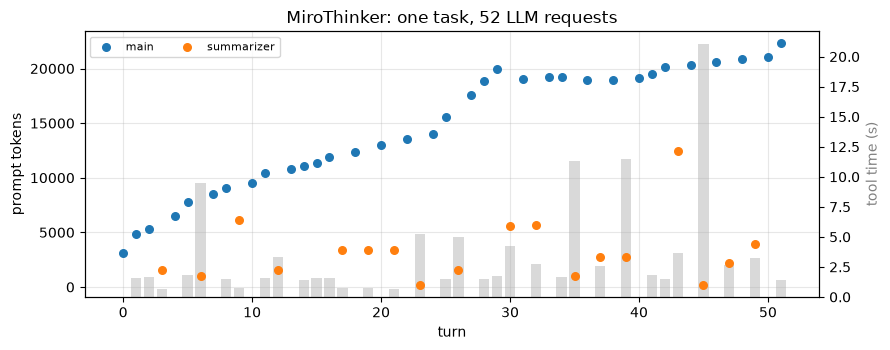

In [6]:
def session_plot(df, title):
    """Prompt length of every turn, coloured by role, with tool time behind it."""
    fig, ax = plt.subplots(figsize=(9, 3.6))
    ax2 = ax.twinx()
    ax2.bar(df["turn"], df["tool_time"], color="0.85", zorder=0, width=.8)
    ax2.set_ylabel("tool time (s)", color="0.5")
    ax2.grid(False)
    for role, g in df.groupby("role"):
        ax.scatter(g["turn"], g["num_prefill_tokens"], label=role, s=30, zorder=3)
    ax.set(xlabel="turn", ylabel="prompt tokens", title=title)
    ax.set_zorder(ax2.get_zorder() + 1)
    ax.patch.set_visible(False)
    ax.legend(fontsize=8, ncol=3, loc="upper left")
    fig.tight_layout()

miro = lsg.gaia_sessions(num_sessions=24, seed=0, agent="mirothinker", max_tokens=None)
one_miro = miro[miro.session == miro.groupby("session").size().idxmax()]
session_plot(one_miro, f"MiroThinker: one task, {len(one_miro)} LLM requests")

The agent's own requests (`main`) climb in a staircase: each turn is the previous
turn plus the tool result, so the prompt only ever grows — about 3,100 tokens at
the start and 22,000 thirty-four turns later. This is the shape that papers on
agent serving usually report, and it is easy to reason about: one conversation,
growing monotonically, one request in flight at a time.

The `summarizer` requests are the part this trace captures that most published
traces do not, and they do not follow the conversation at all. Each one hands a
long scraped page to a cheaper model and gets a couple of hundred tokens back,
which is what the main agent then sees. That is also why the main agent's own
prompt grows as gently as it does: the summariser is absorbing the long documents
on its behalf. A third of the requests in this task are summariser calls, so
"prefill grows monotonically" describes only part of what the serving system
actually receives.

Now the multi-agent system, where there is no single conversation to grow at all.
OWL splits the task across a planner, a coordinator and several workers, each
with its own context.

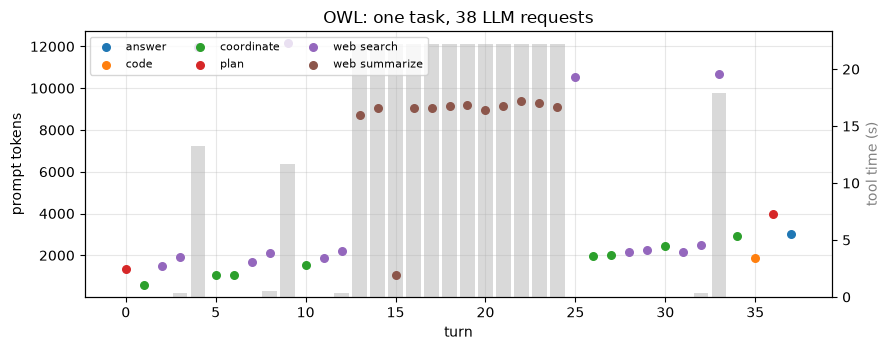

In [7]:
one = sessions[sessions.session == 4]
session_plot(one, f"OWL: one task, {len(one)} LLM requests")

Each dot represents a request from a sub-agent (plan, coordinate, web search, ...),
and when the agent uses a tool, the bar shows the tool execution time.
The prompt length (y-axis of each dot) grows inside a stretch of turns and then drops: each time the
coordinator hands a subtask to a fresh worker, that worker starts a new
conversation with its own system prompt. Within a worker's stretch, every turn
adds a tool result to the prompt. Again, this is how OWL was designed and not necessarily universal.

The flat band of twelve large turns in the middle is the web worker retrieving a long page, splitting it into twelve
pieces, and asking the model to summarise each piece in parallel. This is again a specific design
made by the OWL authors to keep the prompt (prefill) length small and is not fundamental.
You don't have to understand every piece that is happening in this plot, and many things are specific to the
particular design of this agent; having a sense
that multi-agent systems are complex is probably enough.

:::{admonition} Try it
:class: exercise
Change the session id in the code above (`sessions.session == 4`) to another
number and rerun it. Different tasks are solved with quite different patterns of
sub-agents working together. Which one produces the most interesting plot?
:::

## Tokens, time, and tools

Now the whole sample, with the two systems side by side. Three numbers decide
what this traffic does to a serving system: how many tokens go in and out, how
long each kind of token takes, and how much of the time nothing is running at
all because a tool is.

In [8]:
def shape(df):
    return {"requests": len(df),
            "requests per task (median)": df.groupby("session").size().median(),
            "prompt tokens (total)": df.num_prefill_tokens.sum(),
            "output tokens (total)": df.num_decode_tokens.sum(),
            "prompt : output": df.num_prefill_tokens.sum() / df.num_decode_tokens.sum(),
            "median prompt tokens": df.num_prefill_tokens.median(),
            "median output tokens": df.num_decode_tokens.median(),
            "turns waiting on a tool": (df.tool_time > 0).mean(),
            "tool time, median of those (s)": df.loc[df.tool_time > 0, "tool_time"].median()}

pd.DataFrame({"OWL (multi-agent)": shape(sessions),
              "MiroThinker (single agent)": shape(miro)}).round(2)

,OWL (multi-agent),MiroThinker (single agent)
requests,673.00,371.00
requests per task (median),25.00,12.50
prompt tokens (total),1987165.00,4476103.00
output tokens (total),173021.00,149144.00
prompt : output,11.49,30.01
median prompt tokens,1964.00,9154.00
median output tokens,109.00,176.00
turns waiting on a tool,0.34,0.61
"tool time, median of those (s)",0.37,1.53


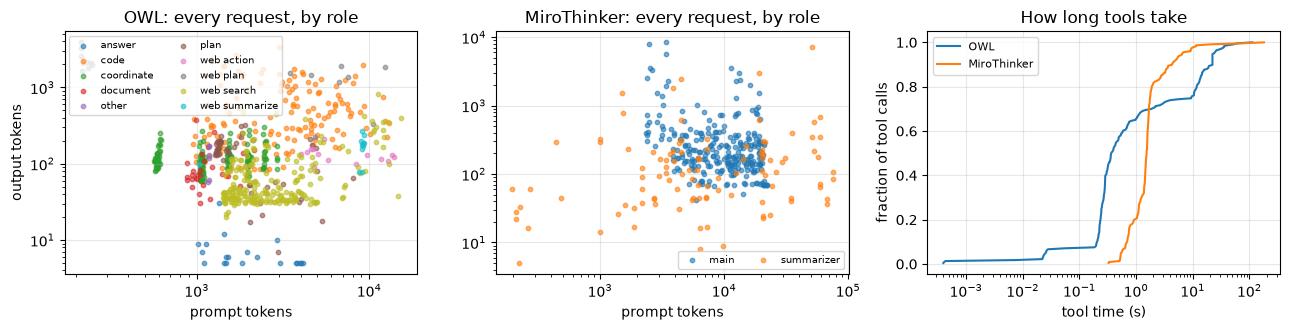

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
for col, (name, df) in enumerate([("OWL", sessions), ("MiroThinker", miro)]):
    for role, g in df.groupby("role"):
        ax[col].scatter(g["num_prefill_tokens"], g["num_decode_tokens"], s=10, alpha=.6, label=role)
    ax[col].set(xlabel="prompt tokens", ylabel="output tokens" if col == 0 else "",
                xscale="log", yscale="log", title=f"{name}: every request, by role")
    ax[col].legend(fontsize=7, ncol=2)
for name, df in [("OWL", sessions), ("MiroThinker", miro)]:
    tool = np.sort(df.loc[df.tool_time > 0, "tool_time"])
    ax[2].plot(tool, np.arange(1, len(tool) + 1) / len(tool), label=name)
ax[2].set(xlabel="tool time (s)", ylabel="fraction of tool calls", xscale="log",
          title="How long tools take")
ax[2].legend(fontsize=8)
fig.tight_layout()

Both systems are **prefill-heavy**, and the single agent much more so: 11 prompt
tokens per output token for OWL, 30 for MiroThinker. The reason is visible in the
scatter plots. OWL's sub-agents form distinct clouds — the coordinator answers
with a worker id, the web-search worker emits a tool call of a few dozen tokens,
the summariser reads a page chunk — while MiroThinker has just two: a main agent
whose prompt grows along the conversation, and a summariser sitting far to the
right with prompts of tens of thousands of tokens and tiny answers.

Tools behave differently too. Two thirds of MiroThinker's turns wait on a tool
against a third of OWL's, and MiroThinker's waits are four times longer at the
median (1.5 s against 0.4 s). Neither system is anywhere near the GPU for that
time.

Prompt and output tokens cost differently, though. A prompt token costs roughly
0.25 ms of GPU time on our simulated replica, while an output token costs about
45 ms — nearly 200× more — because decode is memory-bound (lecture 1). A turn
with 9,000 prompt tokens and 180 output tokens spends a couple of seconds on its
prompt and eight on its answer. So being prefill-heavy does not always mean
prefill is going to be the bottleneck (it may or may not). Another thing to
consider is the prefix cache (lecture 5) — prefill gets much cheaper with a high
prefix cache hit rate, which is where the next lecture starts.

:::{admonition} Try it
:class: exercise
Each recording used two models, so a real deployment is two serving problems
rather than one. Using the `model` column, work out how much GPU time each model
would need: count its prompt and output tokens and price them at the ~0.25 ms and
~45 ms per token above. If you had eight GPUs, how would you split them for OWL,
and how for MiroThinker? Which pool saturates first in each case?
:::

## Summary

| | What we saw |
|---|---|
| A task is not a request | one GAIA task is dozens of dependent LLM requests, and the user waits for the whole chain |
| Single agent | one conversation that only grows: a clean staircase of prompt lengths, plus a summariser whose requests ignore the conversation entirely |
| Multi-agent | no single conversation; each worker starts its own, and a fan-out can release a dozen requests at once |
| Tokens | prefill-heavy in both, 11:1 for OWL and 30:1 for MiroThinker |
| Time | an output token still costs ~200× a prompt token, so prefill-heavy does not mean prefill-bound |
| Tools | a third of OWL's turns and two thirds of MiroThinker's wait on a tool, for 0.4 s and 1.5 s at the median |

{doc}`07-agentic-workloads-2` takes these traces to a GPU: how much of all that
prompt text is reusable, what prefix caching is worth here, and where a task's
time actually goes.

## Check your understanding

Click an answer to check it. Wrong answers can be retried.

In [10]:
#@title Questions (run this cell)
lsg.quiz([
    {"q": "Why does an agent's prompt grow from turn to turn?",
     "options": ["The model remembers more each time",
                 "The model has no memory between requests, so every turn re-sends the conversation plus the new tool output",
                 "The system pads prompts to a block boundary"],
     "answer": 1,
     "explain": "Each request is independent. Continuity is created by resending everything, which is exactly why the prefix cache works so well here."},
    {"q": "Agent traffic has 11--30 prompt tokens per output token. Where does most of the GPU <i>time</i> go?",
     "options": ["Prefill, because there are far more prompt tokens",
                 "Decode, because each output token costs roughly 200\u00d7 more than a prompt token"],
     "answer": 1,
     "explain": "Prefill is compute-bound and processes thousands of tokens per step; decode is memory-bound and produces one token per step per request."},
    {"q": "MiroThinker is a single agent, yet its prompt lengths are not one clean staircase. What breaks the pattern?",
     "options": ["The agent restarts its conversation when it gets too long",
                 "A third of the requests are summariser calls, whose prompts are scraped pages rather than the conversation",
                 "Requests arrive out of order"],
     "answer": 1,
     "explain": "Traces that only record the main loop show a monotonic staircase. The summariser is part of the same system and reaches the same serving stack."},
    {"q": "What does a fan-out in OWL do to the serving system that a single agent never does?",
     "options": ["It releases a dozen requests at the same instant, so they queue behind each other",
                 "It makes the prompts longer",
                 "It bypasses the KV cache"],
     "answer": 0,
     "explain": "A multi-agent system has no single conversation: a coordinator can hand the same instant's work to many workers, and they all arrive together."},
    {"q": "Two thirds of MiroThinker's turns wait on a tool, for 1.5 s at the median. What is the GPU doing then?",
     "options": ["Decoding ahead", "Nothing, for that session \u2014 unless another task's work can fill the gap"],
     "answer": 1,
     "explain": "Tool time is off-GPU. For one task it is dead time; a serving system can only reclaim it by running someone else's request."},
])